### Experiment 02

To develop regression model and evaluate its performance . Predict house price

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv("E06_house price data less.csv")
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,995,Punjab,Ludhiana,Locality_456,Villa,5,3047,425.49,0.14,2010,...,15,2,6,High,Yes,No,"Clubhouse, Garden",North,Owner,Under_Construction
995,996,Telangana,Hyderabad,Locality_375,Apartment,1,1392,87.07,0.06,2005,...,20,9,3,Low,Yes,Yes,"Clubhouse, Garden",East,Broker,Ready_to_Move
996,997,Haryana,Gurgaon,Locality_133,Apartment,2,3252,163.62,0.05,1994,...,31,3,1,High,No,Yes,"Garden, Gym, Playground, Clubhouse, Pool",North,Owner,Under_Construction
997,998,Assam,Silchar,Locality_120,Apartment,2,2601,454.06,0.17,1996,...,29,4,9,Medium,No,Yes,"Clubhouse, Gym",South,Broker,Under_Construction


In [3]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [4]:
df.tail(10)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
989,990,Uttar Pradesh,Lucknow,Locality_398,Villa,2,2185,51.88,0.02,1993,...,32,6,6,Medium,No,Yes,"Garden, Clubhouse, Pool, Gym",West,Builder,Under_Construction
990,991,Uttarakhand,Dehradun,Locality_34,Villa,1,1220,375.21,0.31,2000,...,25,4,2,Low,Yes,No,"Clubhouse, Garden, Gym",South,Broker,Ready_to_Move
991,992,Assam,Guwahati,Locality_212,Apartment,2,2912,313.83,0.11,2007,...,18,10,8,Medium,No,No,"Clubhouse, Playground, Gym, Pool",East,Broker,Under_Construction
992,993,West Bengal,Durgapur,Locality_208,Villa,1,1993,246.09,0.12,1990,...,35,10,9,Low,Yes,Yes,"Pool, Garden",East,Builder,Ready_to_Move
993,994,Delhi,Dwarka,Locality_449,Independent House,5,4731,448.73,0.09,2005,...,20,3,2,High,Yes,No,"Clubhouse, Garden",South,Owner,Under_Construction
994,995,Punjab,Ludhiana,Locality_456,Villa,5,3047,425.49,0.14,2010,...,15,2,6,High,Yes,No,"Clubhouse, Garden",North,Owner,Under_Construction
995,996,Telangana,Hyderabad,Locality_375,Apartment,1,1392,87.07,0.06,2005,...,20,9,3,Low,Yes,Yes,"Clubhouse, Garden",East,Broker,Ready_to_Move
996,997,Haryana,Gurgaon,Locality_133,Apartment,2,3252,163.62,0.05,1994,...,31,3,1,High,No,Yes,"Garden, Gym, Playground, Clubhouse, Pool",North,Owner,Under_Construction
997,998,Assam,Silchar,Locality_120,Apartment,2,2601,454.06,0.17,1996,...,29,4,9,Medium,No,Yes,"Clubhouse, Gym",South,Broker,Under_Construction
998,999,Punjab,Ludhiana,Locality_339,Villa,3,1315,383.61,0.29,1999,...,26,10,7,Low,No,No,"Gym, Playground, Clubhouse, Pool, Garden",South,Builder,Ready_to_Move


In [5]:
df.shape

(999, 23)

## EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              999 non-null    int64  
 1   State                           999 non-null    object 
 2   City                            999 non-null    object 
 3   Locality                        999 non-null    object 
 4   Property_Type                   999 non-null    object 
 5   BHK                             999 non-null    int64  
 6   Size_in_SqFt                    999 non-null    int64  
 7   Price_in_Lakhs                  999 non-null    float64
 8   Price_per_SqFt                  999 non-null    float64
 9   Year_Built                      999 non-null    int64  
 10  Furnished_Status                999 non-null    object 
 11  Floor_No                        999 non-null    int64  
 12  Total_Floors                    999 

In [7]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [8]:
df.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object

In [9]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,500.000000,2.914915,2739.569570,257.066687,0.131752,2006.709710,14.766767,15.428428,18.290290,5.462462,5.391391
std,288.530761,1.426828,1306.529168,141.533299,0.130940,9.921931,8.995137,8.738613,9.921931,2.877308,2.889752
min,1.000000,1.000000,502.000000,11.590000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,250.500000,2.000000,1617.500000,134.655000,0.050000,1998.000000,7.000000,8.000000,9.500000,3.000000,3.000000
50%,500.000000,3.000000,2639.000000,261.840000,0.100000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,749.500000,4.000000,3886.500000,381.735000,0.160000,2015.500000,23.000000,23.000000,27.000000,8.000000,8.000000
max,999.000000,5.000000,5000.000000,499.570000,0.970000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [10]:
df.describe(include="O")

,State,City,Locality,Property_Type,Furnished_Status,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
count,999,999,999,999,999,999,999,999,999,999,999,999
unique,20,42,433,3,3,3,2,2,288,4,3,2
top,Rajasthan,Jaipur,Locality_305,Villa,Semi-furnished,Low,No,No,Gym,East,Owner,Under_Construction
freq,67,42,7,341,351,374,506,525,39,259,360,502


## Pre-Processing

####  Dropping `ID` column since it's irrelevant 

In [11]:
df.drop('ID', axis=1, inplace=True)

#### Dropping `Locality` column since it's doesn't containg meaningful address

In [12]:
df.drop('Locality', axis=1, inplace=True)

In [13]:
df.shape

(999, 21)

#### Using Ordinal Encoder to Encode Ordinal Values

In [14]:
ordinal_columns = ['Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Facing', 'Security']

categories = [['Apartment', 'Independent House', 'Villa'],
              ['Unfurnished', 'Semi-furnished', 'Furnished'],
              ['Low', 'Medium', 'High'],
              ['South', 'East', 'West', 'North'],  
              ['No', 'Yes']]

encoder = OrdinalEncoder(categories=categories)
df[ordinal_columns] = encoder.fit_transform(df[ordinal_columns])

In [15]:
df.head()

,State,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,Tamil Nadu,Chennai,0.0,1,4740,489.76,0.10,1990,2.0,22,...,35,10,3,2.0,No,0.0,"Playground, Gym, Garden, Pool, Clubhouse",2.0,Owner,Ready_to_Move
1,Maharashtra,Pune,1.0,3,2364,195.52,0.08,2008,0.0,21,...,17,8,1,0.0,No,1.0,"Playground, Clubhouse, Pool, Gym, Garden",3.0,Builder,Under_Construction
2,Punjab,Ludhiana,0.0,2,3642,183.79,0.05,1997,1.0,19,...,28,9,8,0.0,Yes,0.0,"Clubhouse, Pool, Playground, Gym",0.0,Broker,Ready_to_Move
3,Rajasthan,Jodhpur,1.0,2,2741,300.29,0.11,1991,2.0,21,...,34,5,7,2.0,Yes,1.0,"Playground, Clubhouse, Gym, Pool, Garden",3.0,Builder,Ready_to_Move
4,Rajasthan,Jaipur,2.0,4,4823,182.90,0.04,2002,1.0,3,...,23,4,9,0.0,No,1.0,"Playground, Garden, Gym, Pool, Clubhouse",1.0,Builder,Ready_to_Move


#### Separating Categorical and Numerical columns

In [16]:
categorical_col = [column for column in df.columns if df[column].dtype == 'object']
numerical_col = [column for column in df.columns if df[column].dtype != 'object']

In [17]:
categorical_col

['State',
 'City',
 'Parking_Space',
 'Amenities',
 'Owner_Type',
 'Availability_Status']

In [18]:
numerical_col

['Property_Type',
 'BHK',
 'Size_in_SqFt',
 'Price_in_Lakhs',
 'Price_per_SqFt',
 'Year_Built',
 'Furnished_Status',
 'Floor_No',
 'Total_Floors',
 'Age_of_Property',
 'Nearby_Schools',
 'Nearby_Hospitals',
 'Public_Transport_Accessibility',
 'Security',
 'Facing']

In [19]:
len(categorical_col), len(numerical_col)

(6, 15)

#### Lower cap strings for better accessibility

In [20]:
"Nagar" == "nagar"

False

In [21]:
for column in categorical_col:
    df[column] = df[column].str.lower()

#### Checking Correlation

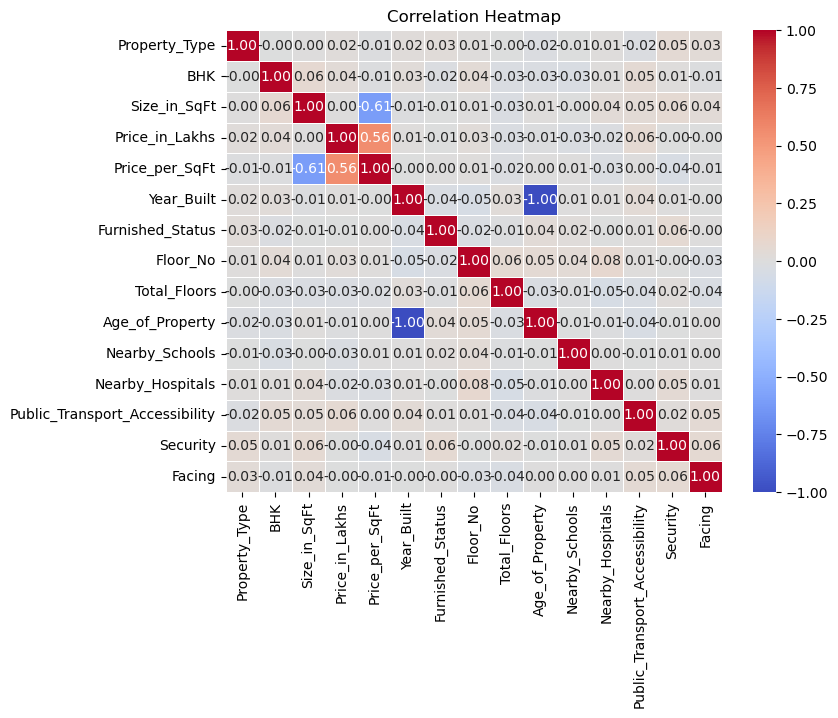

In [22]:
correlation_matrix = df[numerical_col].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### Splitting Dataset and Picking Out Smaller Sample

Reducing **Number of rows** to speed up training due to low compute power

In [23]:
# Randomly sample 40% of the data
df_sampled = df.sample(frac=0.4, random_state=1)

In [24]:
df_sampled

,State,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
507,rajasthan,jaipur,1.0,1,2736,445.96,0.16,2019,1.0,0,...,6,9,7,2.0,no,0.0,"clubhouse, pool, playground",1.0,broker,under_construction
608,haryana,gurgaon,1.0,5,3438,17.27,0.01,2019,0.0,12,...,6,6,2,2.0,yes,0.0,"gym, playground, pool",3.0,broker,ready_to_move
452,jharkhand,ranchi,2.0,2,2583,496.99,0.19,2023,0.0,8,...,2,3,10,2.0,no,1.0,"pool, garden, gym, playground, clubhouse",2.0,owner,ready_to_move
368,haryana,gurgaon,0.0,3,515,110.93,0.22,2008,0.0,29,...,17,4,9,2.0,no,0.0,"playground, pool",3.0,owner,ready_to_move
242,punjab,amritsar,1.0,3,3925,229.96,0.06,1991,1.0,22,...,34,3,10,0.0,no,1.0,"garden, gym, playground",1.0,owner,ready_to_move
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,odisha,bhubaneswar,2.0,1,1677,15.96,0.01,2009,2.0,21,...,16,8,7,0.0,no,1.0,"clubhouse, pool",1.0,owner,under_construction
554,punjab,ludhiana,2.0,4,2881,442.42,0.15,2003,1.0,6,...,22,3,3,0.0,yes,1.0,"clubhouse, garden, gym, pool, playground",2.0,broker,ready_to_move
103,punjab,ludhiana,2.0,4,4925,338.20,0.07,2004,2.0,4,...,21,8,6,0.0,no,1.0,"playground, garden, gym, pool",1.0,owner,under_construction
965,gujarat,ahmedabad,0.0,4,756,29.75,0.04,2012,0.0,15,...,13,6,2,0.0,yes,0.0,"garden, playground, pool, clubhouse, gym",0.0,owner,under_construction


In [25]:
X = df_sampled.drop('Price_in_Lakhs', axis=1)  
y = df_sampled['Price_in_Lakhs']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
len(X_test), len(X_train)

(80, 320)

#### Encoding Categorical Variables
- DictVectorizer automatically handles categorical columns

In [27]:
train_dicts = X_train.to_dict(orient='records') # using resampled data as our train feature
test_dicts = X_test.to_dict(orient='records')

In [28]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

## Training The Model
- Training Using Different Models and Evaluating Their Results
- Helper function and list to evaluate models and store scores

In [29]:
model_results = []

def evaluate_model(y, y_pred):
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    
    return mae, mse, rmse, r2

In [30]:
model_results

[]

## Linear Regression

In [31]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [32]:
y_pred = model.predict(X_test)
mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)
mae, mse, rmse, r2

(118.76992756464406,
 21936.66018554235,
 np.float64(148.11029736497846),
 0.031172053792077548)

In [33]:
model_results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
})

In [34]:
model_results

[{'Model': 'Linear Regression',
  'MAE': 118.76992756464406,
  'MSE': 21936.66018554235,
  'RMSE': np.float64(148.11029736497846),
  'R2': 0.031172053792077548}]

In [35]:
model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

model.fit(X_train, y_train)
y_pred1 = model.predict(X_test)

mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 118.76992756464406
MSE : 21936.66018554235
RMSE : 148.11029736497846
R2 : 0.031172053792077548


In [36]:
accuracy = r2_score(y_test, y_pred1)
accuracy

0.9022065772914465

In [37]:
import pickle

# Train Decision Tree
model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

# Save Model
with open("house_price_model.pkl","wb") as f:
    pickle.dump(model,f)

# Save DictVectorizer
with open("vectorizer.pkl","wb") as f:
    pickle.dump(dv,f)

# Save Ordinal Encoder
with open("encoder.pkl","wb") as f:
    pickle.dump(encoder,f)

# Save Feature Names
with open("features.pkl","wb") as f:
    pickle.dump(X.columns.tolist(),f)

print("All files saved successfully.")

MAE : 35.20508541666667
MSE : 2214.284890042014
RMSE : 47.056188647637136
R2 Score : 0.9022065772914465
All files saved successfully.


### Conclusion

In this experiment, regression models using Linear Regression and Decision Tree were developed to predict house prices. Both models were trained and evaluated using appropriate performance metrics. Linear Regression provided a simple and interpretable model, while Decision Tree captured non-linear relationships more effectively. Overall, both techniques proved useful for house price prediction, with performance depending on the nature of the dataset.